### Get started with KANs

Initialize KAN

In [1]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cuda
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [2]:
from kan.utils import create_dataset
# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

Plot KAN at initialization

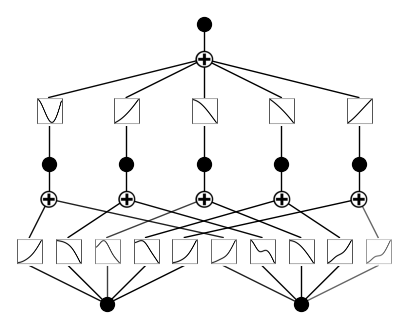

In [3]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot()

Train KAN with sparsity regularization

In [4]:
# train the model
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, profile=True);

| train_loss: 1.35e-01 | test_loss: 1.29e-01 | reg: 1.72e+01 | :   2%| | 1/50 [00:00<00:48,  1.01it/STAGE:2025-05-09 18:11:22 1245396:1245396 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 2.66e-02 | test_loss: 2.80e-02 | reg: 1.65e+01 | :   8%| | 4/50 [00:02<00:31,  1.47it/STAGE:2025-05-09 18:11:25 1245396:1245396 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-09 18:11:25 1245396:1245396 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.93e-02 | test_loss: 1.87e-02 | reg: 5.88e+00 | : 100%|█| 50/50 [00:46<00:00,  1.07it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::bmm         0.44%      11.781ms         0.82%      21.956ms      65.345us     209.058ms        49.78%     209.736ms     624.214us           0 b           0 b      23.13 Mb      12.98 M

Plot trained KAN

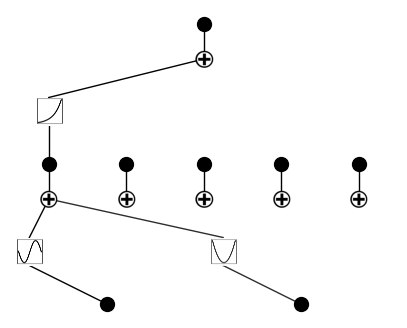

In [5]:
model.plot()

## Try Quantized Models

In [6]:
from kan.QuantKAN import QuantKAN
quantized_model = QuantKAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


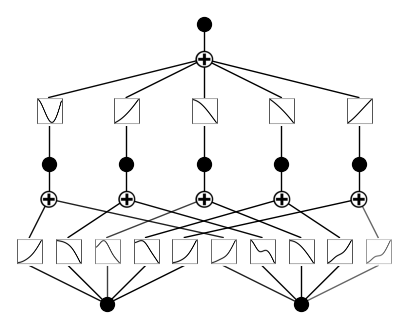

In [7]:
# plot KAN at initialization
quantized_model(dataset['train_input']);
quantized_model.plot()

In [8]:
# train the model
quantized_model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, profile=True);

| train_loss: 1.35e-01 | test_loss: 1.29e-01 | reg: 1.72e+01 | :   2%| | 1/50 [00:00<00:22,  2.21it/STAGE:2025-05-09 18:12:20 1245396:1245396 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 2.66e-02 | test_loss: 2.80e-02 | reg: 1.65e+01 | :   8%| | 4/50 [00:02<00:27,  1.66it/STAGE:2025-05-09 18:12:23 1245396:1245396 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-09 18:12:23 1245396:1245396 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 2.01e-02 | test_loss: 2.00e-02 | reg: 5.74e+00 | : 100%|█| 50/50 [00:47<00:00,  1.06it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::bmm         0.44%      11.664ms         0.81%      21.632ms      64.381us     212.998ms        49.93%     213.712ms     636.048us           0 b           0 b      23.13 Mb      12.98 M